# Advanced - wide-area visual streaming export

This notebook demonstrates a wide, shallow bounds mosaic that crosses many Sentinel-2 scenes while writing directly to GeoTIFF. It uses the `visual` TCI asset only, so the output is a compact RGB product rather than a multi-band reflectance stack.

## Why direct export?

For large areas, avoid returning the mosaic as a NumPy array. Passing `output_path` or `output_dir` lets S2Mosaic stream output tiles into a GeoTIFF, keeping peak memory bounded by tile-sized work buffers rather than the full raster.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio

from s2mosaic import mosaic

## 1. Define a very wide, low-height area

This strip is deliberately much wider than it is tall. It spans ~1,000 km of longitude across south-west Western Australia, crossing UTM zones 50 and 51 — so the AOI can't be expressed in a single UTM CRS, and lon/lat (`input_crs=4326`, the default) is the natural input. The output CRS is auto-picked from the bbox centroid (UTM 50S here).

`bounds=` fills the reprojected envelope of the input rectangle — for this AOI that's a few km taller than the curved-in-UTM region at the eastern end, so the output extent is slightly larger than the original lon/lat box. There's no implicit mask: pass `aoi=shapely.geometry.box(*bounds)` if you need pixels outside the original lat/lon rectangle to be nodata.

The example uses 80 m output pixels so the notebook demos the tiled/streaming workflow without creating a huge local file by default.

In [ ]:
# Wide, shallow strip across south-west Western Australia.
wide_bounds = (114.80, -32.35, 125.20, -31.75)

output_path = Path("output/wa_wide_visual_80m.tif")
metadata_path = output_path.with_suffix(".json")

## 2. Stream the mosaic to GeoTIFF

This cell is network-heavy and can take a while. The important scaling controls are `resolution`, `tile_workers`, and direct export via `output_path`. Use `resolution=80` for an exploratory product, try `resolution=10` when you really need native visual resolution and have time/storage for it.

In [3]:
out_path = mosaic(
    bounds=wide_bounds,
    start_year=2023,
    start_month=1,
    duration_months=2,
    bands=["visual"],
    mosaic_method="mean",
    max_observations=2,
    scene_order="valid_data",
    cloud_mask="SCL",
    resolution=80,
    resampling_method="nearest",
    tile_workers=4,
    additional_query={"eo:cloud_cover": {"lt": 60}},
    output_path=output_path,
    show_progress=True,
    overwrite=True,
    include_observation_count=True,
)

print(f"Saved to: {out_path}")

Phase 1: streaming SCL cloud masks:   0%|          | 0/535 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (mean):   0%|          | 0/1722 [00:00<?, ?read/s]

Saved to: output/wa_wide_visual_80m_v2.tif


## 3. Inspect the GeoTIFF without loading it all

Open the exported raster with rasterio and inspect dimensions, CRS, transform, and metadata. This reads headers and the JSON sidecar, not the full image.

In [4]:
with rio.open(out_path) as src:
    print(f"Size: {src.width:,} x {src.height:,} pixels")
    print(f"Bands: {src.count}")
    print(f"CRS: {src.crs}")
    print(f"Pixel size: {src.transform.a}m")

metadata = json.loads(metadata_path.read_text())
summary = {
    "mode": metadata["mode"],
    "start_date": metadata["start_date"],
    "end_date": metadata["end_date"],
}
summary.update(
    {
        key: metadata["request"][key]
        for key in ["bands", "mosaic_method", "resolution", "tile_workers"]
    }
)
print(summary)

Size: 12,328 x 1,203 pixels
Bands: 4
CRS: EPSG:32751
Pixel size: 80.0m
{'mode': 'bounds', 'start_date': '2023-01-01', 'end_date': '2023-03-01', 'bands': ['visual'], 'mosaic_method': 'mean', 'resolution': 80, 'tile_workers': 4}


## 4. Read a small preview

The preview uses `out_shape` to downsample while reading. That keeps notebook memory use small even when the source GeoTIFF is very wide.

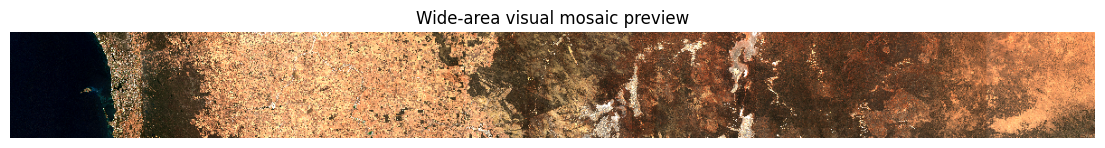

In [5]:
with rio.open(out_path) as src:
    preview_width = 1200
    preview_height = max(1, round(src.height * preview_width / src.width))
    preview = src.read([1, 2, 3], out_shape=(3, preview_height, preview_width))

preview_rgb = np.moveaxis(preview, 0, -1)
if preview_rgb.dtype != np.uint8:
    valid = preview_rgb[np.isfinite(preview_rgb) & (preview_rgb > 0)]
    lo, hi = np.nanpercentile(valid, [2, 98])
    preview_rgb = np.clip((preview_rgb - lo) / max(hi - lo, 1), 0, 1)

plt.figure(figsize=(14, 3))
plt.imshow(preview_rgb)
plt.title("Wide-area visual mosaic preview")
plt.axis("off")
plt.show()

## Scaling up

To push this pattern to a larger production export, keep `bands=["visual"]`, write directly to `output_path`, start with `resolution=60`, then lower the resolution value only after you have checked runtime and file size. Increase `tile_workers` cautiously: higher values can improve throughput for network-bound reads, but also increase simultaneous remote reads and memory pressure.

For AOIs wider than ~6° of longitude (one UTM zone) — e.g. continent-scale exports — the auto-picked centroid UTM becomes a poor fit at the eastern and western ends, with growing scale distortion and a larger envelope overshoot far from the central meridian. For those, pass an explicit `output_crs` to a continent-scale equal-area projection: **EPSG:3577** (GDA94 / Australian Albers) for Australia, **EPSG:5070** for the contiguous US, **ESRI:54009** (Mollweide) for global products. The envelope stays tight and pixel sizes stay uniformly metric across the whole AOI.